In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Buildig the dataset
np.random.seed(42)
dates = pd.date_range(start = '2023-01-01' , end = '2024-12-31',freq = 'D')
categories = ['Electronics', 'Clothing', 'Groceries', 'Furniture']

data = pd.DataFrame({
    'date' : np.random.choice(dates , 500),
    'category' : np.random.choice(categories,500),
    'sales': np.random.randint(100, 5000, 500)
})

data = data.sort_values('date').reset_index(drop = True)
print(data.head())
print(data.shape)

        date     category  sales
0 2023-01-02    Furniture   2497
1 2023-01-02    Furniture   3700
2 2023-01-02  Electronics   2697
3 2023-01-05    Groceries   3729
4 2023-01-05  Electronics   2008
(500, 3)


In [3]:
#Date column ko datetime banao
data['date'] = pd.to_datetime(data['date'])

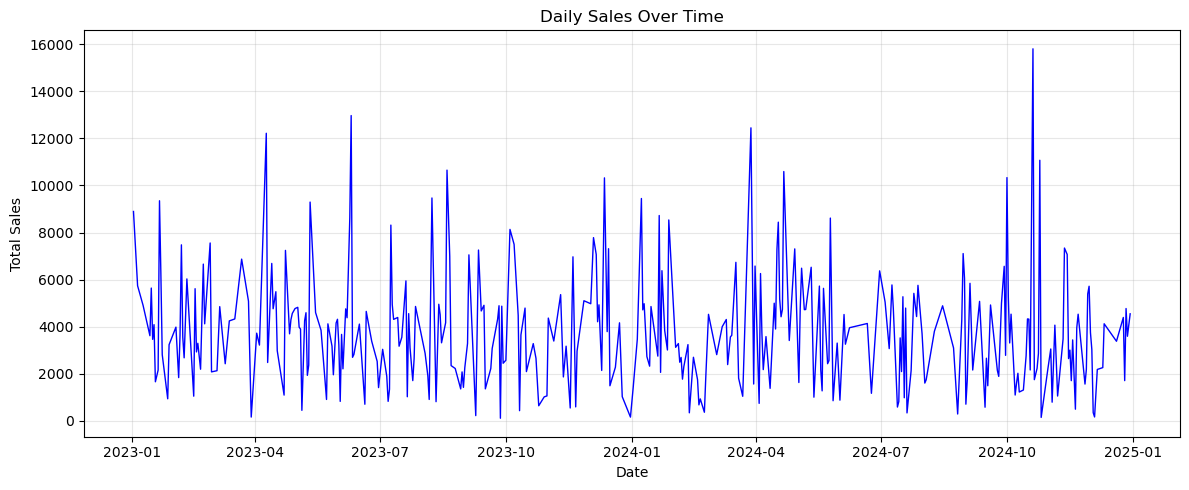

In [4]:
#Line chart 
daily_sales = data.groupby('date')['sales'].sum()

plt.figure(figsize=(12,5))
plt.plot(daily_sales.index , daily_sales.values , color = 'blue',linewidth = 1)
plt.title('Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True , alpha = 0.3)
plt.tight_layout()
plt.savefig("daily_sales.png")
plt.show()

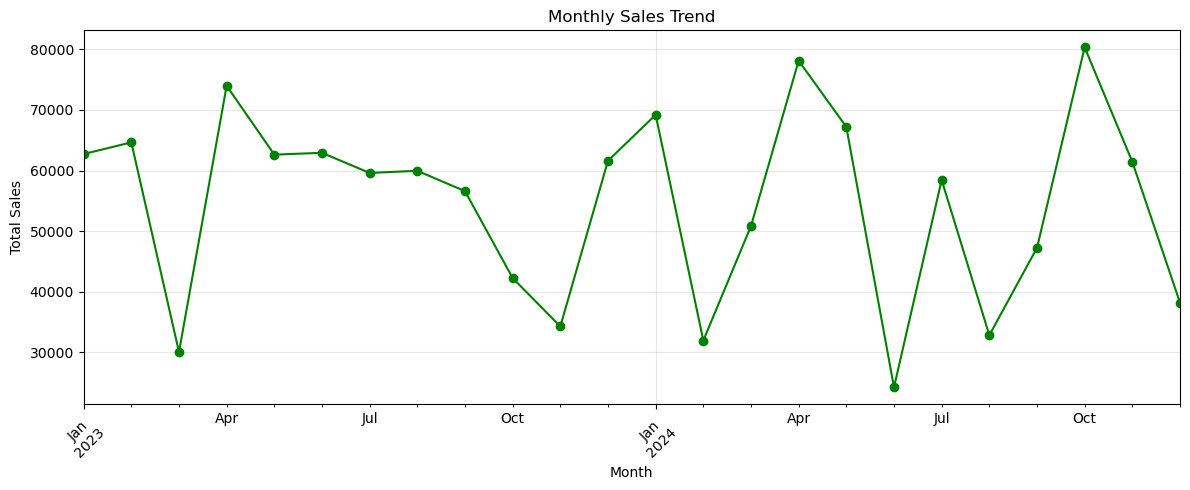

In [5]:
#Monthly aggregation
data['month'] = data['date'].dt.to_period('M')
monthly_sales = data.groupby('month')['sales'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot(kind = 'line' , marker= 'o' , color = 'green')
plt.title("Monthly")
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True , alpha = 0.3)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.savefig('monthly_sales.png')
plt.show()

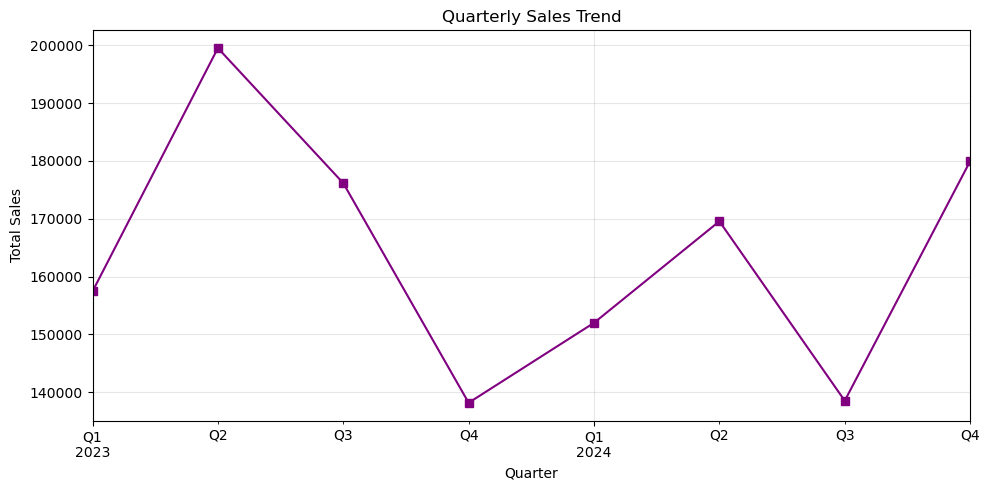

In [9]:
data['quarter'] = data['date'].dt.to_period('Q')
quarterly_sales = data.groupby('quarter')['sales'].sum()

plt.figure(figsize=(10, 5))
quarterly_sales.plot(kind='line', marker='s', color='purple')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('quarterly_sales.png')
plt.show()

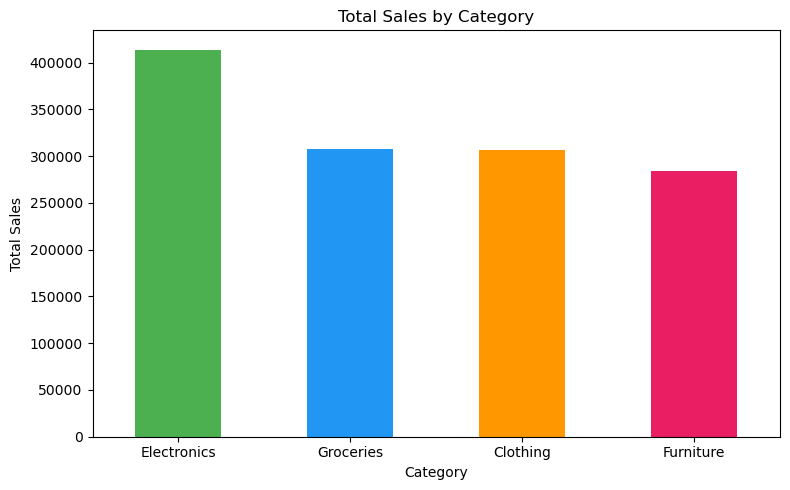

In [12]:
#Bar Chart
category_sales = data.groupby('category')['sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
category_sales.plot(kind='bar', color=['#4CAF50', '#2196F3', '#FF9800', '#E91E63'])
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('category_bar.png')
plt.show()

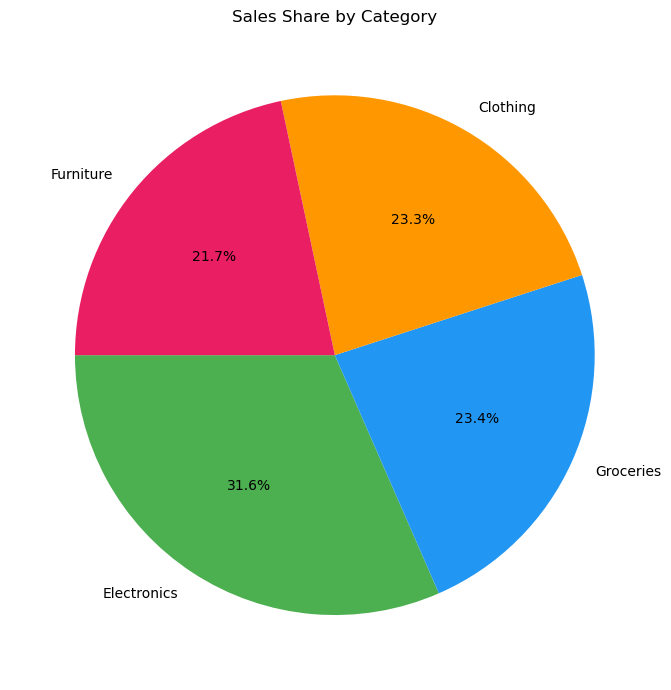

In [16]:
#Pie Chart
plt.figure(figsize=(7, 7))
plt.pie(category_sales.values, labels=category_sales.index, autopct='%1.1f%%', 
        colors=['#4CAF50', '#2196F3', '#FF9800', '#E91E63'], startangle=180)
plt.title('Sales Share by Category')
plt.tight_layout()
plt.savefig('category_pie.png')
plt.show()

In [17]:
summary = f"""
Total Records: {len(data)}
Date Range: {data['date'].min().date()} to {data['date'].max().date()}
Total Sales: {data['sales'].sum()}
Average Daily Sales: {daily_sales.mean():.2f}

Sales by Category:
{category_sales.to_string()}

Best Performing Month:
{monthly_sales.idxmax()} with sales of {monthly_sales.max()}

Best Performing Quarter:
{quarterly_sales.idxmax()} with sales of {quarterly_sales.max()}
"""

print(summary)

with open('summary_report.txt', 'w') as f:
    f.write(summary)

print("\nAll charts saved as PNG!")
print("Summary report saved!")


Total Records: 500
Date Range: 2023-01-02 to 2024-12-30
Total Sales: 1311276
Average Daily Sales: 3789.82

Sales by Category:
category
Electronics    413811
Groceries      307311
Clothing       306086
Furniture      284068

Best Performing Month:
2024-10 with sales of 80309

Best Performing Quarter:
2023Q2 with sales of 199499


All charts saved as PNG!
Summary report saved!
